# 01 EDA und Feature-Auswahl

Ziel: Dry-Bean-Datensatz laden, Klassenverteilung und Feature-Korrelationen untersuchen und eine erste Auswahl von 5 bis 10 Features begruenden.

## Forschungsfrage

Inwiefern lassen sich Dry-Bean-Sorten anhand weniger morphologischer Bildmerkmale zuverlaessig klassifizieren, und welche Merkmale erklaeren die Entscheidungen verschiedener Multiclass-Klassifikatoren am staerksten?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Daten laden

Der Datensatz wird direkt aus dem UCI Machine Learning Repository geladen.

In [9]:
dry_bean = fetch_ucirepo(id=602)
X = dry_bean.data.features
y = dry_bean.data.targets.squeeze()
df = X.copy()
df["Class"] = y

df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
df.shape, df.isna().sum().sum(), df["Class"].value_counts()

((13611, 17),
 0,
 Class
 DERMASON    3546
 SIRA        2636
 SEKER       2027
 HOROZ       1928
 CALI        1630
 BARBUNYA    1322
 BOMBAY       522
 Name: count, dtype: int64)

## Klassenverteilung

Die Klassenverteilung ist wichtig, weil Accuracy bei unausgeglichenen Klassen alleine nicht ausreicht. Deshalb wird spaeter auch Macro-F1 verwendet.

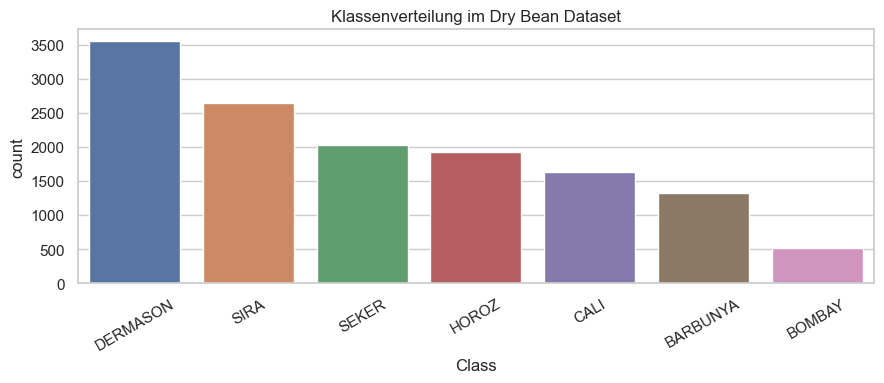

In [4]:
plt.figure(figsize=(9, 4))
sns.countplot(data=df, x="Class", order=df["Class"].value_counts().index)
plt.title("Klassenverteilung im Dry Bean Dataset")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Korrelationen

Stark korrelierte Features liefern oft aehnliche Information. Fuer eine interpretierbare Feature-Auswahl sollten redundante Groessenmerkmale nicht alle gleichzeitig verwendet werden.

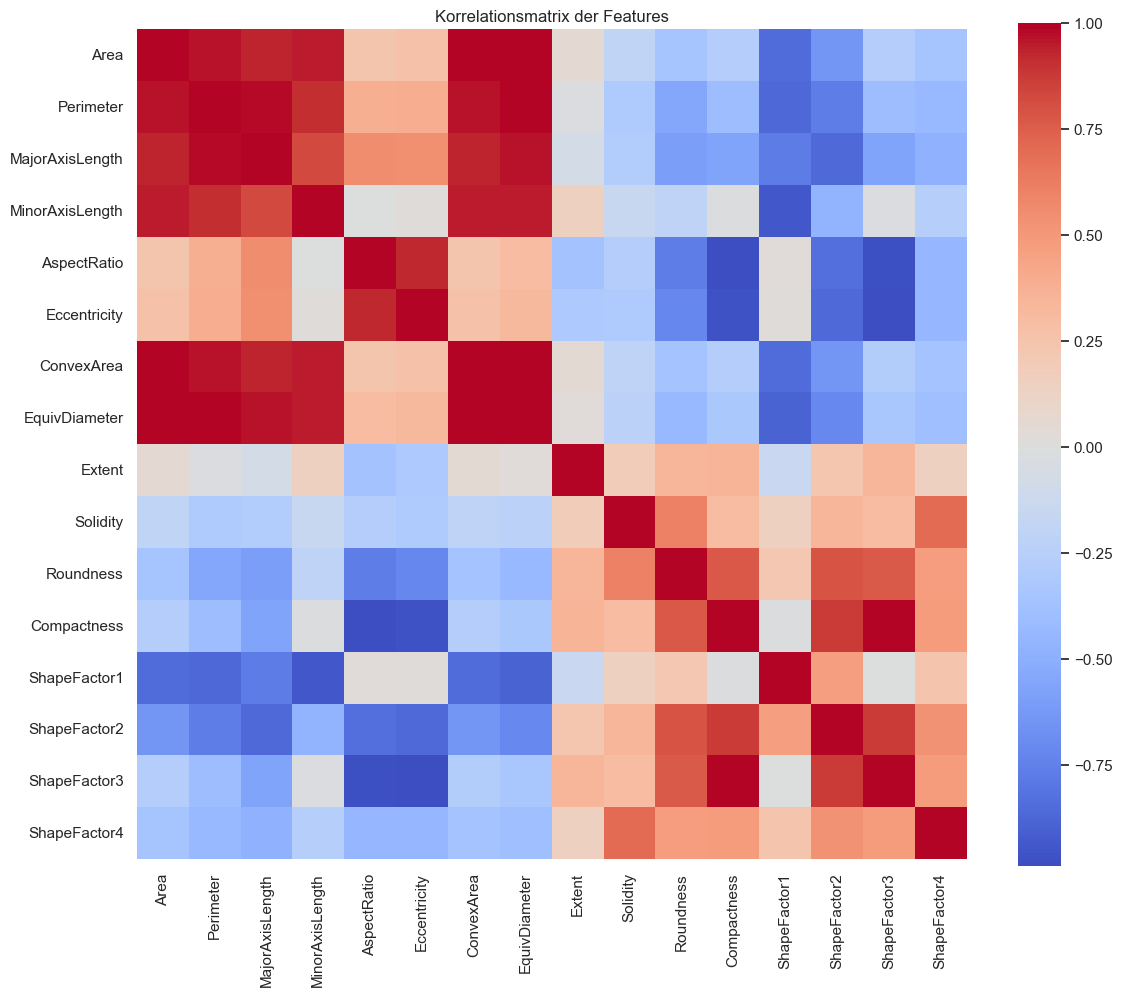

In [5]:
corr = X.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Korrelationsmatrix der Features")
plt.tight_layout()
plt.show()

In [6]:
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
    .query("abs_corr >= 0.90")
    .sort_values("abs_corr", ascending=False)
)
high_corr_pairs

,feature_1,feature_2,abs_corr
5,Area,ConvexArea,0.999939
112,Compactness,ShapeFactor3,0.998686
20,Perimeter,EquivDiameter,0.991380
60,AspectRatio,Compactness,0.987687
75,ConvexArea,EquivDiameter,0.985226
6,Area,EquivDiameter,0.984968
73,Eccentricity,ShapeFactor3,0.981058
63,AspectRatio,ShapeFactor3,0.978592
15,Perimeter,MajorAxisLength,0.977338
70,Eccentricity,Compactness,0.970313


## Erste Feature-Auswahl

Vorschlag fuer eine erste, interpretierbare Auswahl:

- `Area`: Groesse der Bohne
- `AspectRatio`: Verhaeltnis von Laenge zu Breite
- `Eccentricity`: Rundheit bzw. Laenglichkeit
- `Compactness`: Kompaktheit der Form
- `Roundness`: Rundheitsmerkmal
- `ShapeFactor1`, `ShapeFactor2`, `ShapeFactor3`: ergaenzende Formfaktoren

Diese Auswahl kombiniert Groesse und Form, vermeidet aber mehrere stark redundante Groessenfeatures wie `Area`, `ConvexArea` und `EquivDiameter` gleichzeitig.

In [ ]:
selected_features = [
    "Area",
    "AspectRatio",
    "Eccentricity",
    "Compactness",
    "Roundness",
    "ShapeFactor1",
    "ShapeFactor2",
    "ShapeFactor4",
]

df[selected_features + ["Class"]].head()

,Area,AspectRatio,Eccentricity,Compactness,Roundness,ShapeFactor1,ShapeFactor2,ShapeFactor3,Class
0,28395,1.197191,0.549812,0.913358,0.958027,0.007332,0.003147,0.834222,SEKER
1,28734,1.097356,0.411785,0.953861,0.887034,0.006979,0.003564,0.909851,SEKER
2,29380,1.209713,0.562727,0.908774,0.947849,0.007244,0.003048,0.825871,SEKER
3,30008,1.153638,0.498616,0.928329,0.903936,0.007017,0.003215,0.861794,SEKER
4,30140,1.060798,0.333680,0.970516,0.984877,0.006697,0.003665,0.941900,SEKER
